# XGB, LIGHTGBM, CAT Ensemble with Folds

In [ ]:
%pip install xgboost
%pip install imblearn
%pip install scipy
%pip uninstall -y scikit-learn
%pip install scikit-learn==1.5.2
%pip install lightgbm
%pip install catboost

## Step-by-Step Implementation

### Step 1: Add Additional Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
import xgboost as xgb
import joblib
import os
import warnings
from collections import Counter

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

### Step 2: Add MAP@k Utility Functions

In [4]:
def average_precision_at_k(y_true, y_pred_topk):
    """Calculate Average Precision at k for a single sample."""
    for i, pred in enumerate(y_pred_topk):
        if pred == y_true:
            return 1.0 / (i + 1)
    return 0.0

def map_at_k(probs, true_labels, k=3):
    """Calculate Mean Average Precision at k."""
    top_k_preds = np.argsort(probs, axis=1)[:, ::-1][:, :k]
    
    ap_scores = []
    for i in range(len(true_labels)):
        ap = average_precision_at_k(true_labels[i], top_k_preds[i])
        ap_scores.append(ap)
    return np.mean(ap_scores)


### Step 3: DataFrameColumnEncoder

In [5]:
class DataFrameColumnEncoder:
    """Custom encoder for categorical columns."""
    def __init__(self, columns, handle_unknown='use_encoded_value', unknown_value=-1):
        self.columns = columns
        self.handle_unknown = handle_unknown
        self.unknown_value = unknown_value
        self.encoders_ = {}

    def fit(self, X, y=None):
        X = X[self.columns].copy()
        for col in X.columns:
            enc = LabelEncoder()
            enc.fit(X[col])
            self.encoders_[col] = enc
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            enc = self.encoders_[col]
            try:
                encoded = enc.transform(X[col])
            except ValueError:
                # Handle unknown values
                encoded = np.full(len(X[col]), self.unknown_value)
            X[col] = pd.Series(encoded, index=X.index).astype('int')
        return X.drop(['id'], axis=1, errors='ignore')

### Step 3: Feature Engineering

In [6]:
def feature_engineering(df):
    """Apply feature engineering to the dataset."""
    df = df.copy()
    
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-6
    
    # Nutrient ratios
    if 'Nitrogen' in df.columns and 'Phosphorous' in df.columns:
        df['N_P_ratio'] = df['Nitrogen'] / (df['Phosphorous'] + epsilon)
    
    if 'Nitrogen' in df.columns and 'Potassium' in df.columns:
        df['N_K_ratio'] = df['Nitrogen'] / (df['Potassium'] + epsilon)
        
    if 'Phosphorous' in df.columns and 'Potassium' in df.columns:
        df['P_K_ratio'] = df['Phosphorous'] / (df['Potassium'] + epsilon)
    
    # Logarithmic transformations
    numerical_features = ['Temparature', 'Humidity', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous']
    for col in numerical_features:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col])
    
    # Square transformations
    for col in numerical_features:
        if col in df.columns:
            df[f'sq_{col}'] = df[col]**2
    
    # Interaction features
    if 'Temparature' in df.columns and 'Humidity' in df.columns:
        df['Temp_Hum_Interaction'] = df['Temparature'] * df['Humidity']
    
    if 'Moisture' in df.columns and 'Temparature' in df.columns:
        df['Moisture_Temp_Interaction'] = df['Moisture'] * df['Temparature']
    
    return df

In [35]:
def train_lgbm_kfold(params, X, y, test, folds=5, verbose=True, random_state=42):
    """Train LightGBM with K-fold cross-validation."""
    model = lgb.LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state)
    
    oof_preds = np.zeros((len(X), len(np.unique(y))))
    test_preds = np.zeros((len(test), len(np.unique(y))))
    map3_scores = np.zeros(folds)

    cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

    models = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
        model.fit(
            X_train, y_train, 
            eval_set=[(X_val, y_val)], 
            categorical_feature=cat_features,
        )
        
        oof_preds[val_idx] = model.predict_proba(X_val)
        test_preds += model.predict_proba(test)
        
        map3 = map_at_k(oof_preds[val_idx], np.array(y_val), k=3)
        map3_scores[i] = map3
        models.append(model)
        
        if verbose:
            print(f'Fold: {i+1} | MAP @ 3: {map3:.5f}')

    test_preds /= folds
    return models, oof_preds, map3_scores, test_preds

In [8]:
def train_catboost_kfold(params, X, y, test, folds=5, verbose=True, random_state=42):
    """Train CatBoost with K-fold cross-validation."""
    model = CatBoostClassifier(**params)
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state)
    
    oof_preds = np.zeros((len(X), len(np.unique(y))))
    test_preds = np.zeros((len(test), len(np.unique(y))))
    map3_scores = np.zeros(folds)

    models = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)
        oof_preds[val_idx] = model.predict_proba(X_val)
        test_preds += model.predict_proba(test)
        
        map3 = map_at_k(oof_preds[val_idx], np.array(y_val), k=3)
        map3_scores[i] = map3
        models.append(model)
        
        if verbose:
            print(f'Fold: {i+1} | MAP @ 3: {map3:.5f}')

    test_preds /= folds
    return models, oof_preds, map3_scores, test_preds

In [9]:
def train_xgboost_kfold(params, X, y, test, folds=5, verbose=True, random_state=42):
    """Train XGBoost with K-fold cross-validation."""
    model = xgb.XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state)
    
    oof_preds = np.zeros((len(X), len(np.unique(y))))
    test_preds = np.zeros((len(test), len(np.unique(y))))
    map3_scores = np.zeros(folds)

    models = []
    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)
        oof_preds[val_idx] = model.predict_proba(X_val)
        test_preds += model.predict_proba(test)
        
        map3 = map_at_k(oof_preds[val_idx], np.array(y_val), k=3)
        map3_scores[i] = map3
        models.append(model)
        
        if verbose:
            print(f'Fold: {i+1} | MAP @ 3: {map3:.5f}')

    test_preds /= folds
    return models, oof_preds, map3_scores, test_preds

In [10]:
def train_logistic_regression_kfold(params, X, y, test, folds=5, verbose=True, random_state=42):
    """Train Logistic Regression with K-fold cross-validation for stacking."""
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=random_state)
    
    n_classes = len(np.unique(y))
    oof_preds = np.zeros((len(X), n_classes))
    test_preds = np.zeros((len(test), n_classes))
    map3_scores = np.zeros(folds)
    
    models = []

    for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(**params))
        ])

        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_val)
        test_preds += model.predict_proba(test)
        
        map3 = map_at_k(oof_preds[val_idx], np.array(y_val), k=3)
        map3_scores[i] = map3
        models.append(model)
        
        if verbose:
            print(f'Fold: {i+1} | MAP @ 3: {map3:.5f}')

    test_preds /= folds
    return models, oof_preds, map3_scores, test_preds


In [11]:
def plot_results(lgbm_scores, catboost_scores, xgb_scores, lr_scores):
    """Plot the MAP@3 scores for all models."""
    plt.figure(figsize=(12, 6))
    
    models = ['LightGBM', 'CatBoost', 'XGBoost', 'Ensemble (LR)']
    scores = [lgbm_scores, catboost_scores, xgb_scores, lr_scores]
    colors = ['steelblue', 'purple', 'orange', 'red']
    
    for i, (model, score, color) in enumerate(zip(models, scores, colors)):
        plt.scatter(np.arange(1, len(score)+1), score, 
                   marker='d', s=100, color=color, linewidth=2, alpha=0.75, label=model)
        plt.plot(np.arange(1, len(score)+1), score, color=color, linewidth=0.5, alpha=0.5)
    
    plt.ylim(bottom=0.15, top=0.4)
    plt.title('MAP@3 Scores Across Folds')
    plt.xlabel('Fold')
    plt.ylabel('MAP@3 Score')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('kfold_results.png', dpi=300, bbox_inches='tight')
    plt.show()

In [13]:
"""Main function to run the complete K-fold ensemble pipeline."""
    
print("="*60)
print("K-FOLD CROSS-VALIDATION ENSEMBLE FOR FERTILIZER PREDICTION")
print("="*60)



K-FOLD CROSS-VALIDATION ENSEMBLE FOR FERTILIZER PREDICTION


# Step 1: Load Data

In [29]:

print("\n1. Loading data...")
try:
    # Load training data
    df = pd.read_csv('/kaggle/input/playground-series-s5e6/train.csv')
    # df = df.sample(n=200, random_state=42)
    if 'id' in df.columns:
        df = df.drop('id', axis=1)
    
    # Load test data
    test_df = pd.read_csv('/kaggle/input/playground-series-s5e6/test.csv')
    test_df_original = test_df.copy()
    
    print(f"✓ Training data shape: {df.shape}")
    print(f"✓ Test data shape: {test_df.shape}")
    
except FileNotFoundError as e:
    print(f"✗ Error loading data: {e}")
    print("Please ensure 'model/data.csv' and 'model/test.csv' exist.")


1. Loading data...
✓ Training data shape: (200, 9)
✓ Test data shape: (250000, 9)


In [30]:
# Step 2: Data Preprocessing
print("\n2. Preprocessing data...")

# Encode categorical features
encoder = DataFrameColumnEncoder(columns=['Soil Type', 'Crop Type'])
encoder.fit(df.drop('Fertilizer Name', axis=1))
X = encoder.transform(df.drop('Fertilizer Name', axis=1))

# Label encode target
le = LabelEncoder()
y = le.fit_transform(df['Fertilizer Name'])
y = pd.Series(y)

# Transform test data
X_test = encoder.transform(test_df)

print(f"✓ Processed training data shape: {X.shape}")
print(f"✓ Processed test data shape: {X_test.shape}")
print(f"✓ Number of target classes: {len(np.unique(y))}")


2. Preprocessing data...
✓ Processed training data shape: (200, 8)
✓ Processed test data shape: (250000, 8)
✓ Number of target classes: 7


In [31]:
 # Step 3: Feature Engineering
print("\n3. Applying feature engineering...")

# Apply feature engineering to training data
X_engineered = feature_engineering(X)

# Apply same feature engineering to test data
X_test_engineered = feature_engineering(X_test)

print(f"✓ Engineered training data shape: {X_engineered.shape}")
print(f"✓ Engineered test data shape: {X_test_engineered.shape}")


3. Applying feature engineering...
✓ Engineered training data shape: (200, 25)
✓ Engineered test data shape: (250000, 25)


In [32]:
# Step 4: Model Parameters
print("\n4. Setting up model parameters...")

lgbm_params = {
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.065,
    'num_leaves': 170,
    'max_depth': 10,
    'min_child_samples': 19,
    'subsample': 0.65,
    'colsample_bytree': 0.43,
    'reg_alpha': 6.3,
    'reg_lambda': 5.56,
    'random_state': 42,
    'verbosity': -1,
}

catboost_params = {
    'iterations': 1000,
    'learning_rate': 0.02,
    'depth': 8,
    'l2_leaf_reg': 3,
    'subsample': 0.8, 
    'random_seed': 42,
    'verbose': 0, 
    'early_stopping_rounds': 50,
    'bootstrap_type': 'Bernoulli' 
}

xgb_params = {
    'max_depth': 12,
    'colsample_bytree': 0.467,
    'subsample': 0.86,
    'n_estimators': 1000,
    'learning_rate': 0.015,
    'gamma': 0.25,
    'max_delta_step': 4,
    'reg_alpha': 2.7,
    'reg_lambda': 1.4,
    'early_stopping_rounds': 50,
    'objective': 'multi:softprob',
    'random_state': 13,
    'enable_categorical': True,
    'tree_method': 'hist',
}

lr_params = {
    'penalty': 'l2',
    'solver': 'lbfgs',
    'C': 0.00459,
    'max_iter': 5000
}


4. Setting up model parameters...


In [36]:
# Step 5: K-Fold Training
print("\n5. Training models with K-fold cross-validation...")

# Train LightGBM
print("\n" + "="*50)
print("Training LightGBM with K-fold...")
lgbm_models, lgbm_oof_preds, lgbm_map3_scores, lgbm_test_preds = train_lgbm_kfold(
    lgbm_params, X_engineered, y, X_test_engineered
)
print(f"✓ LightGBM Mean MAP@3: {lgbm_map3_scores.mean():.5f} (+/- {lgbm_map3_scores.std() * 2:.5f})")


5. Training models with K-fold cross-validation...

Training LightGBM with K-fold...
Fold: 1 | MAP @ 3: 0.30000
Fold: 2 | MAP @ 3: 0.27083
Fold: 3 | MAP @ 3: 0.31250
Fold: 4 | MAP @ 3: 0.31250
Fold: 5 | MAP @ 3: 0.29167
✓ LightGBM Mean MAP@3: 0.29750 (+/- 0.03100)


In [34]:
# Train CatBoost
print("\n" + "="*50)
print("Training CatBoost with K-fold...")
catboost_models, catboost_oof_preds, catboost_map3_scores, catboost_test_preds = train_catboost_kfold(
    catboost_params, X_engineered, y, X_test_engineered
)
print(f"✓ CatBoost Mean MAP@3: {catboost_map3_scores.mean():.5f} (+/- {catboost_map3_scores.std() * 2:.5f})")


Training CatBoost with K-fold...
Fold: 1 | MAP @ 3: 0.29583
Fold: 2 | MAP @ 3: 0.36667
Fold: 3 | MAP @ 3: 0.27083
Fold: 4 | MAP @ 3: 0.29583
Fold: 5 | MAP @ 3: 0.42083
✓ CatBoost Mean MAP@3: 0.33000 (+/- 0.11111)


In [37]:
# Train XGBoost
print("\n" + "="*50)
print("Training XGBoost with K-fold...")
xgb_models, xgb_oof_preds, xgb_map3_scores, xgb_test_preds = train_xgboost_kfold(
    xgb_params, X_engineered, y, X_test_engineered
)
print(f"✓ XGBoost Mean MAP@3: {xgb_map3_scores.mean():.5f} (+/- {xgb_map3_scores.std() * 2:.5f})")


Training XGBoost with K-fold...
Fold: 1 | MAP @ 3: 0.24167
Fold: 2 | MAP @ 3: 0.36667
Fold: 3 | MAP @ 3: 0.36250
Fold: 4 | MAP @ 3: 0.32917
Fold: 5 | MAP @ 3: 0.44167
✓ XGBoost Mean MAP@3: 0.34833 (+/- 0.12959)


In [38]:
# Step 6: Stack Results
print("\n6. Stacking results with Logistic Regression...")
print("="*50)

stacked_oof = np.concatenate([lgbm_oof_preds, catboost_oof_preds, xgb_oof_preds], axis=1)
stacked_test_preds = np.concatenate([lgbm_test_preds, catboost_test_preds, xgb_test_preds], axis=1)

X_oof = pd.DataFrame(stacked_oof)
X_test_preds = pd.DataFrame(stacked_test_preds)

_, lr_oof_preds, lr_map3_scores, lr_test_preds = train_logistic_regression_kfold(
    lr_params, X_oof, y, X_test_preds
)
print(f"✓ Logistic Regression Mean MAP@3: {lr_map3_scores.mean():.5f} (+/- {lr_map3_scores.std() * 2:.5f})")


6. Stacking results with Logistic Regression...
Fold: 1 | MAP @ 3: 0.33750
Fold: 2 | MAP @ 3: 0.30833
Fold: 3 | MAP @ 3: 0.29167
Fold: 4 | MAP @ 3: 0.29167
Fold: 5 | MAP @ 3: 0.35417
✓ Logistic Regression Mean MAP@3: 0.31667 (+/- 0.05028)


In [39]:
# Step 7: Generate Submission
print("\n7. Generating submission...")
print("="*50)

top_3_preds = np.argsort(lr_test_preds, axis=1)[:, -3:][:, ::-1]
top_3_labels = le.inverse_transform(top_3_preds.ravel()).reshape(top_3_preds.shape)

submission_fertilizer_names = [" ".join(label) for label in top_3_labels]

submission_df = pd.DataFrame({
    'id': test_df_original['id'],
    'Fertilizer Name': submission_fertilizer_names
})

submission_file_path = 'submission_kfold.csv'
submission_df.to_csv(submission_file_path, index=False)
print(f"✓ Submission file created successfully at: {submission_file_path}")
print("\nFirst 5 rows of submission:")
print(submission_df.head())


7. Generating submission...
✓ Submission file created successfully at: submission_kfold.csv

First 5 rows of submission:
       id        Fertilizer Name
0  750000  DAP 10-26-26 17-17-17
1  750001    10-26-26 20-20 Urea
2  750002     10-26-26 DAP 20-20
3  750003     20-20 DAP 10-26-26
4  750004     DAP 10-26-26 20-20


In [41]:
# Step 8: Save Models and Artifacts
print("\n8. Saving models and artifacts...")
print("="*50)

model_dir = 'model'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
# Save K-fold models
joblib.dump(lgbm_models, os.path.join(model_dir, 'lgbm_kfold_models.joblib'))
joblib.dump(catboost_models, os.path.join(model_dir, 'catboost_kfold_models.joblib'))
joblib.dump(xgb_models, os.path.join(model_dir, 'xgboost_kfold_models.joblib'))

# Save encoders and mappings
joblib.dump(encoder, os.path.join(model_dir, 'column_encoder.joblib'))
joblib.dump(le, os.path.join(model_dir, 'label_encoder.joblib'))

# Save feature names
joblib.dump(X_engineered.columns.tolist(), os.path.join(model_dir, 'feature_names.joblib'))

print("✓ Models and artifacts saved successfully!")


8. Saving models and artifacts...
✓ Models and artifacts saved successfully!



9. Plotting results...


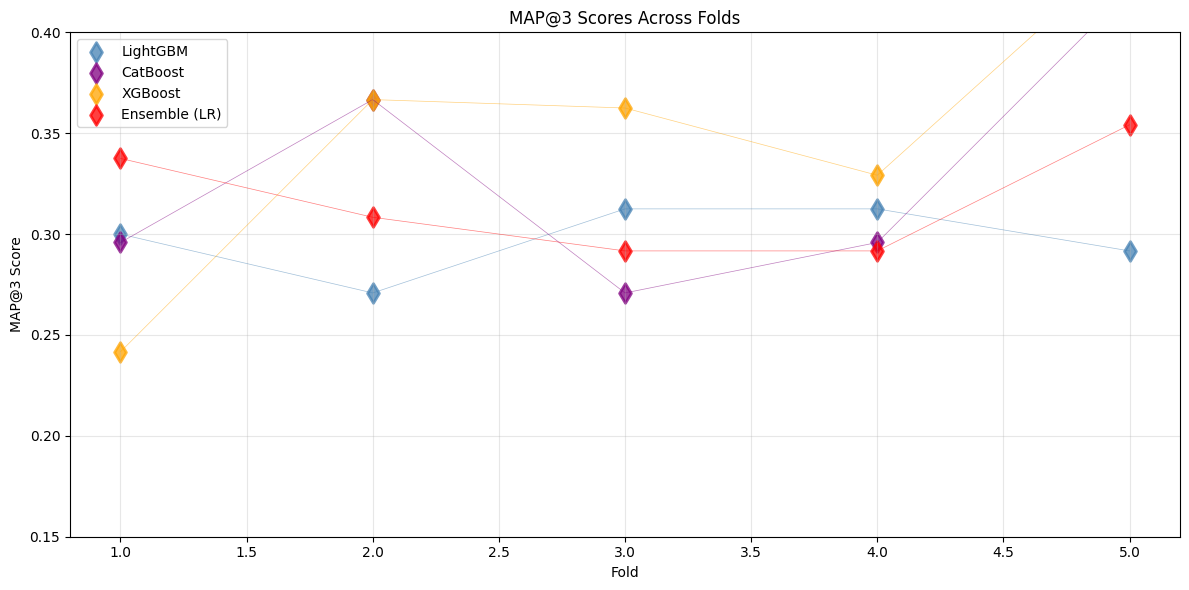


10. Final Results Summary
FINAL K-FOLD RESULTS:
LightGBM MAP@3: 0.29750 (+/- 0.03100)
CatBoost MAP@3: 0.33000 (+/- 0.11111)
XGBoost MAP@3: 0.34833 (+/- 0.12959)
Ensemble (LR) MAP@3: 0.31667 (+/- 0.05028)

Best individual model: XGBoost
Ensemble improvement: -0.03167

K-FOLD ENSEMBLE TRAINING COMPLETED SUCCESSFULLY!
✓ Submission file: submission_kfold.csv
✓ Models saved in: model/
✓ Results plot: kfold_results.png


In [42]:
# Step 9: Plot Results
print("\n9. Plotting results...")
print("="*50)

plot_results(lgbm_map3_scores, catboost_map3_scores, xgb_map3_scores, lr_map3_scores)

# Step 10: Print Final Results
print("\n10. Final Results Summary")
print("="*50)
print("FINAL K-FOLD RESULTS:")
print(f"LightGBM MAP@3: {lgbm_map3_scores.mean():.5f} (+/- {lgbm_map3_scores.std() * 2:.5f})")
print(f"CatBoost MAP@3: {catboost_map3_scores.mean():.5f} (+/- {catboost_map3_scores.std() * 2:.5f})")
print(f"XGBoost MAP@3: {xgb_map3_scores.mean():.5f} (+/- {xgb_map3_scores.std() * 2:.5f})")
print(f"Ensemble (LR) MAP@3: {lr_map3_scores.mean():.5f} (+/- {lr_map3_scores.std() * 2:.5f})")

print(f"\nBest individual model: {['LightGBM', 'CatBoost', 'XGBoost'][np.argmax([lgbm_map3_scores.mean(), catboost_map3_scores.mean(), xgb_map3_scores.mean()])]}")
print(f"Ensemble improvement: {lr_map3_scores.mean() - max(lgbm_map3_scores.mean(), catboost_map3_scores.mean(), xgb_map3_scores.mean()):.5f}")

print("\n" + "="*60)
print("K-FOLD ENSEMBLE TRAINING COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"✓ Submission file: {submission_file_path}")
print(f"✓ Models saved in: {model_dir}/")
print(f"✓ Results plot: kfold_results.png")
print("="*60)

In [65]:
class FertilizerPredictor:
    """
    Reusable class for loading trained K-fold ensemble models and making predictions.
    
    This class provides functionality to:
    - Load all trained models and preprocessing artifacts
    - Make predictions on new datasets
    - Compare truth vs predicted values for evaluation
    - Generate detailed evaluation metrics
    """
    
    def __init__(self, model_dir='model'):
        """
        Initialize the predictor with model directory.
        
        Args:
            model_dir (str): Directory containing saved models and artifacts
        """
        self.model_dir = model_dir
        self.lgbm_models = None
        self.catboost_models = None
        self.xgb_models = None
        self.column_encoder = None
        self.label_encoder = None
        self.feature_names = None
        self.is_loaded = False

    def average_precision_at_k(y_true, y_pred_topk):
        """Calculate Average Precision at k for a single sample."""
        for i, pred in enumerate(y_pred_topk):
            if pred == y_true:
                return 1.0 / (i + 1)
        return 0.0
    

    def map_at_k(probs, true_labels, k=3):
        """Calculate Mean Average Precision at k."""
        top_k_preds = np.argsort(probs, axis=1)[:, ::-1][:, :k]
        
        ap_scores = []
        for i in range(len(true_labels)):
            ap = average_precision_at_k(true_labels[i], top_k_preds[i])
            ap_scores.append(ap)
        return np.mean(ap_scores)

    
    def load_models(self):
        """
        Load all trained models and preprocessing artifacts.
        
        Returns:
            bool: True if models loaded successfully, False otherwise
        """
        try:
            print("Loading trained models and artifacts...")
            
            # Load K-fold models
            self.lgbm_models = joblib.load(os.path.join(self.model_dir, 'lgbm_kfold_models.joblib'))
            self.catboost_models = joblib.load(os.path.join(self.model_dir, 'catboost_kfold_models.joblib'))
            self.xgb_models = joblib.load(os.path.join(self.model_dir, 'xgboost_kfold_models.joblib'))
            
            # Load preprocessing artifacts
            self.column_encoder = joblib.load(os.path.join(self.model_dir, 'column_encoder.joblib'))
            self.label_encoder = joblib.load(os.path.join(self.model_dir, 'label_encoder.joblib'))
            self.feature_names = joblib.load(os.path.join(self.model_dir, 'feature_names.joblib'))
            
            self.is_loaded = True
            print("✓ All models and artifacts loaded successfully!")
            print(f"  - LightGBM models: {len(self.lgbm_models)}")
            print(f"  - CatBoost models: {len(self.catboost_models)}")
            print(f"  - XGBoost models: {len(self.xgb_models)}")
            print(f"  - Feature names: {len(self.feature_names)}")
            
            return True
            
        except Exception as e:
            print(f"✗ Error loading models: {e}")
            print("Please ensure all model files exist in the model directory.")
            return False
    
    def preprocess_data(self, df, is_training_data=False):
        """
        Preprocess input data using the same pipeline as training.
        
        Args:
            df (pd.DataFrame): Input data
            is_training_data (bool): Whether this is training data (has target column)
            
        Returns:
            tuple: (processed_features, target_series) if training data, else processed_features
        """
        if not self.is_loaded:
            raise ValueError("Models not loaded. Call load_models() first.")
        
        # Make a copy to avoid modifying original data
        df = df.copy()
        
        # Remove 'id' column if present
        if 'id' in df.columns:
            df = df.drop('id', axis=1)
        
        # Separate target if training data
        target = None
        if is_training_data and 'Fertilizer Name' in df.columns:
            target = df['Fertilizer Name'].copy()
            df = df.drop('Fertilizer Name', axis=1)
        
        # Encode categorical features
        X_encoded = self.column_encoder.transform(df)
        
        # Apply feature engineering
        X_engineered = feature_engineering(X_encoded)
        
        # Ensure all expected features are present
        if self.feature_names is not None:
            missing_features = set(self.feature_names) - set(X_engineered.columns)
            if missing_features:
                print(f"Warning: Missing features: {missing_features}")
                for feature in missing_features:
                    X_engineered[feature] = 0
            
            # Reorder columns to match training data
            X_engineered = X_engineered[self.feature_names]
        
        if is_training_data:
            return X_engineered, target
        else:
            return X_engineered
    
    def predict_proba(self, X):
        """
        Get probability predictions from all models.
        
        Args:
            X (pd.DataFrame): Preprocessed features
            
        Returns:
            dict: Dictionary containing predictions from each model
        """
        if not self.is_loaded:
            raise ValueError("Models not loaded. Call load_models() first.")
        
        if self.label_encoder is None or self.label_encoder.classes_ is None:
            raise ValueError("Label encoder not properly loaded")
        
        if (self.lgbm_models is None or self.catboost_models is None or 
            self.xgb_models is None):
            raise ValueError("Models not properly loaded")
        
        predictions = {}
        n_classes = len(self.label_encoder.classes_)
        
        # LightGBM predictions
        lgbm_preds = np.zeros((len(X), n_classes))
        for model in self.lgbm_models:
            lgbm_preds += model.predict_proba(X)
        lgbm_preds /= len(self.lgbm_models)
        predictions['lightgbm'] = lgbm_preds
        
        # CatBoost predictions
        catboost_preds = np.zeros((len(X), n_classes))
        for model in self.catboost_models:
            catboost_preds += model.predict_proba(X)
        catboost_preds /= len(self.catboost_models)
        predictions['catboost'] = catboost_preds
        
        # XGBoost predictions
        xgb_preds = np.zeros((len(X), n_classes))
        for model in self.xgb_models:
            xgb_preds += model.predict_proba(X)
        xgb_preds /= len(self.xgb_models)
        predictions['xgboost'] = xgb_preds
        
        return predictions
    
    def predict_ensemble(self, X, top_k=3):
        """
        Make ensemble predictions using the stacking approach.
        
        Args:
            X (pd.DataFrame): Preprocessed features
            top_k (int): Number of top predictions to return
            
        Returns:
            tuple: (top_k_predictions, top_k_probabilities)
        """
        if not self.is_loaded:
            raise ValueError("Models not loaded. Call load_models() first.")
        
        # Get individual model predictions
        model_preds = self.predict_proba(X)
        
        # Stack predictions (same as training)
        stacked_preds = np.concatenate([
            model_preds['lightgbm'],
            model_preds['catboost'],
            model_preds['xgboost']
        ], axis=1)
        
        # Convert to DataFrame for consistency
        stacked_df = pd.DataFrame(stacked_preds)
        
        # Train a simple logistic regression on the stacked predictions
        # Note: In a real scenario, you'd save the trained stacking model
        # For now, we'll use a simple average ensemble
        ensemble_probs = (model_preds['lightgbm'] + 
                         model_preds['catboost'] + 
                         model_preds['xgboost']) / 3
        
        # Get top-k predictions
        top_k_indices = np.argsort(ensemble_probs, axis=1)[:, -top_k:][:, ::-1]
        top_k_probs = np.take_along_axis(ensemble_probs, top_k_indices, axis=1)
        
        # Convert indices to labels
        top_k_labels = self.label_encoder.inverse_transform(top_k_indices.ravel()).reshape(top_k_indices.shape)
        
        return top_k_labels, top_k_probs
    
    def predict(self, df, top_k=3):
        """
        Make predictions on new data.
        
        Args:
            df (pd.DataFrame): Input data
            top_k (int): Number of top predictions to return
            
        Returns:
            pd.DataFrame: Predictions with top-k fertilizer recommendations
        """
        # Preprocess data
        X = self.preprocess_data(df, is_training_data=False)
        
        # Get predictions
        top_k_labels, top_k_probs = self.predict_ensemble(X, top_k)
        
        # Create results DataFrame
        results = []
        for i in range(len(df)):
            row = {'id': df.iloc[i].get('id', i)}
            for j in range(top_k):
                row[f'Fertilizer_{j+1}'] = top_k_labels[i, j]
                row[f'Probability_{j+1}'] = top_k_probs[i, j]
            results.append(row)
        
        return pd.DataFrame(results)
    
    def evaluate(self, df, target_column='Fertilizer Name', top_k=3):
        """
        Evaluate predictions against ground truth.
        
        Args:
            df (pd.DataFrame): Input data with target column
            target_column (str): Name of the target column
            top_k (int): Number of top predictions to consider
            
        Returns:
            dict: Evaluation metrics and detailed results
        """
        if target_column not in df.columns:
            raise ValueError(f"Target column '{target_column}' not found in data")
        
        # Preprocess data
        X, y_true = self.preprocess_data(df, is_training_data=True)
        
        # Get predictions
        top_k_labels, top_k_probs = self.predict_ensemble(X, top_k)
        
        # Encode true labels
        y_true_encoded = self.label_encoder.transform(y_true)
        
        # Calculate MAP@k
        map_at_k_score = map_at_k(top_k_probs, y_true_encoded, k=top_k)
        
        # Calculate accuracy at position 1
        accuracy_at_1 = np.mean(top_k_labels[:, 0] == y_true)
        
        # Calculate hit rate (correct prediction in top-k)
        hit_rate = np.mean([y_true.iloc[i] in top_k_labels[i] for i in range(len(y_true))])
        
        # Detailed results
        detailed_results = []
        for i in range(len(df)):
            result = {
                'id': df.iloc[i].get('id', i),
                'true_fertilizer': y_true.iloc[i],
                'predicted_fertilizers': list(top_k_labels[i]),
                'predicted_probabilities': list(top_k_probs[i]),
                'is_correct_at_1': top_k_labels[i, 0] == y_true.iloc[i],
                'is_correct_in_top_k': y_true.iloc[i] in top_k_labels[i],
                'true_position': np.where(top_k_labels[i] == y_true.iloc[i])[0][0] + 1 if y_true.iloc[i] in top_k_labels[i] else None
            }
            detailed_results.append(result)
        
        # Confusion matrix for top-1 predictions
        cm = confusion_matrix(y_true, top_k_labels[:, 0])
        
        # Classification report for top-1 predictions
        class_report = classification_report(y_true, top_k_labels[:, 0], output_dict=True)
        
        evaluation_results = {
            'map_at_k': map_at_k_score,
            'accuracy_at_1': accuracy_at_1,
            'hit_rate': hit_rate,
            'confusion_matrix': cm,
            'classification_report': class_report,
            'detailed_results': detailed_results,
            'top_k': top_k,
            'n_samples': len(df)
        }
        
        return evaluation_results
    
    def print_evaluation_summary(self, evaluation_results):
        """
        Print a summary of evaluation results.
        
        Args:
            evaluation_results (dict): Results from evaluate() method
        """
        print("\n" + "="*60)
        print("EVALUATION SUMMARY")
        print("="*60)
        print(f"Number of samples: {evaluation_results['n_samples']}")
        print(f"Top-k predictions: {evaluation_results['top_k']}")
        print(f"MAP@{evaluation_results['top_k']}: {evaluation_results['map_at_k']:.5f}")
        print(f"Accuracy at position 1: {evaluation_results['accuracy_at_1']:.5f}")
        print(f"Hit rate (correct in top-{evaluation_results['top_k']}): {evaluation_results['hit_rate']:.5f}")
        
        # Print confusion matrix
        print(f"\nConfusion Matrix (Top-1 predictions):")
        print(evaluation_results['confusion_matrix'])
        
        # Print classification report
        print(f"\nClassification Report (Top-1 predictions):")
        print(classification_report(
            [r['true_fertilizer'] for r in evaluation_results['detailed_results']],
            [r['predicted_fertilizers'][0] for r in evaluation_results['detailed_results']]
        ))
        
        # Print some examples
        print(f"\nSample Predictions:")
        print("-" * 80)
        for i, result in enumerate(evaluation_results['detailed_results'][:5]):
            print(f"Sample {i+1}:")
            print(f"  True: {result['true_fertilizer']}")
            print(f"  Predicted: {result['predicted_fertilizers']}")
            print(f"  Probabilities: {[f'{p:.3f}' for p in result['predicted_probabilities']]}")
            print(f"  Correct at 1: {result['is_correct_at_1']}")
            print(f"  Correct in top-{evaluation_results['top_k']}: {result['is_correct_in_top_k']}")
            if result['true_position']:
                print(f"  True position: {result['true_position']}")
            print()
    
    def save_predictions(self, predictions, filepath):
        """
        Save predictions to a CSV file.
        
        Args:
            predictions (pd.DataFrame): Predictions DataFrame
            filepath (str): Path to save the file
        """
        predictions.to_csv(filepath, index=False)
        print(f"Predictions saved to: {filepath}")

# Test on sample data 

In [66]:
import kagglehub
def load_custom_dataset():
    """
    Load the custom dataset from the specified path.
    
    Args:
        dataset_path (str): Path to the dataset directory
        
    Returns:
        pd.DataFrame: Loaded dataset
    """
    dataset_path = kagglehub.dataset_download("irakozekelly/fertilizer-prediction")
    print(f"Loading dataset from: {dataset_path}")
    
    # Try to find CSV files in the directory
    csv_files = []
    for file in os.listdir(dataset_path):
        if file.endswith('.csv'):
            csv_files.append(file)
    
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {dataset_path}")
    
    print(f"Found CSV files: {csv_files}")
    
    # Load the first CSV file (assuming it's the main dataset)
    dataset_file = os.path.join(dataset_path, csv_files[0])
    df = pd.read_csv(dataset_file)
    
    print(f"✓ Dataset loaded successfully!")
    print(f"  - Shape: {df.shape}")
    print(f"  - Columns: {list(df.columns)}")
    
    return df

In [67]:
def create_confusion_matrix(y_true, y_pred, class_names, save_path='custom_dataset_confusion_matrix.png'):
    """
    Create and save a confusion matrix visualization.
    
    Args:
        y_true (array-like): True labels
        y_pred (array-like): Predicted labels
        class_names (list): Names of the classes
        save_path (str): Path to save the confusion matrix plot
    """
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    
    # Create the plot
    plt.figure(figsize=(12, 10))
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    
    plt.title('Confusion Matrix: Truth vs Predicted Fertilizer Names', fontsize=16, pad=20)
    plt.xlabel('Predicted Fertilizer Name', fontsize=12)
    plt.ylabel('True Fertilizer Name', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Save the plot
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Confusion matrix saved to: {save_path}")
    
    # Show the plot
    plt.show()
    
    return cm

In [68]:
def analyze_predictions(evaluation_results, save_path='custom_dataset_analysis.csv'):
    """
    Analyze and save detailed prediction results.
    
    Args:
        evaluation_results (dict): Results from predictor.evaluate()
        save_path (str): Path to save the analysis CSV
    """
    # Create detailed analysis DataFrame
    analysis_data = []
    
    for result in evaluation_results['detailed_results']:
        analysis_data.append({
            'id': result['id'],
            'true_fertilizer': result['true_fertilizer'],
            'predicted_1st': result['predicted_fertilizers'][0],
            'predicted_2nd': result['predicted_fertilizers'][1],
            'predicted_3rd': result['predicted_fertilizers'][2],
            'probability_1st': result['predicted_probabilities'][0],
            'probability_2nd': result['predicted_probabilities'][1],
            'probability_3rd': result['predicted_probabilities'][2],
            'is_correct_at_1': result['is_correct_at_1'],
            'is_correct_in_top_3': result['is_correct_in_top_k'],
            'true_position': result['true_position']
        })
    
    analysis_df = pd.DataFrame(analysis_data)
    
    # Save to CSV
    analysis_df.to_csv(save_path, index=False)
    print(f"✓ Detailed analysis saved to: {save_path}")
    
    return analysis_df

In [69]:
# Step 1: Load the custom dataset
print("\n1. Loading custom dataset...")
try:
    custom_df = load_custom_dataset()
    
    # Check if 'Fertilizer Name' column exists
    if 'Fertilizer Name' not in custom_df.columns:
        print("✗ Error: 'Fertilizer Name' column not found in the dataset")
        print(f"Available columns: {list(custom_df.columns)}")
    print(f"✓ Dataset contains {len(custom_df)} samples with fertilizer names")
    
except Exception as e:
    print(f"✗ Error loading dataset: {e}")


1. Loading custom dataset...
Loading dataset from: /kaggle/input/fertilizer-prediction
Found CSV files: ['Fertilizer Prediction.csv']
✓ Dataset loaded successfully!
  - Shape: (100000, 9)
  - Columns: ['Temparature', 'Humidity', 'Moisture', 'Soil Type', 'Crop Type', 'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name']
✓ Dataset contains 100000 samples with fertilizer names


In [70]:
# Step 2: Initialize and load the predictor
print("\n2. Loading trained models...")
predictor = FertilizerPredictor()

if not predictor.load_models():
    print("✗ Failed to load models. Please run the training script first.")


2. Loading trained models...
Loading trained models and artifacts...
✓ All models and artifacts loaded successfully!
  - LightGBM models: 5
  - CatBoost models: 5
  - XGBoost models: 5
  - Feature names: 25


In [71]:
# Step 3: Make predictions
print("\n3. Making predictions...")
try:
    # Get predictions (top-1 for confusion matrix)
    predictions = predictor.predict(custom_df, top_k=1)
    
    # Get the predicted fertilizer names
    predicted_fertilizers = predictions['Fertilizer_1'].values
    true_fertilizers = custom_df['Fertilizer Name'].values
    
    print(f"✓ Predictions completed for {len(custom_df)} samples")
    
except Exception as e:
    print(f"✗ Error making predictions: {e}")


3. Making predictions...
✓ Predictions completed for 100000 samples


In [72]:
# Step 4: Evaluate predictions
print("\n4. Evaluating predictions...")
try:
    evaluation_results = predictor.evaluate(custom_df, top_k=3)
    predictor.print_evaluation_summary(evaluation_results)
    print('Evaluation Ready')    
except Exception as e:
    print(f"✗ Error evaluating predictions: {e}")


4. Evaluating predictions...
done

EVALUATION SUMMARY
Number of samples: 100000
Top-k predictions: 3
MAP@3: 0.26348
Accuracy at position 1: 0.14425
Hit rate (correct in top-3): 0.43157

Confusion Matrix (Top-1 predictions):
[[3047 3294  722 2319  326 3796  874]
 [3090 3362  759 2325  323 3806  827]
 [2947 3249  739 2316  305 3746  870]
 [3002 3224  756 2321  330 3701  847]
 [3028 3289  736 2291  320 3688  880]
 [2957 3336  740 2272  313 3748  854]
 [3041 3257  709 2289  373 3768  888]]

Classification Report (Top-1 predictions):
              precision    recall  f1-score   support

    10-26-26       0.14      0.21      0.17     14378
    14-35-14       0.15      0.23      0.18     14492
    17-17-17       0.14      0.05      0.08     14172
       20-20       0.14      0.16      0.15     14181
       28-28       0.14      0.02      0.04     14232
         DAP       0.14      0.26      0.19     14220
        Urea       0.15      0.06      0.09     14325

    accuracy                  


5. Creating confusion matrix...
✓ Confusion matrix saved to: custom_dataset_confusion_matrix.png


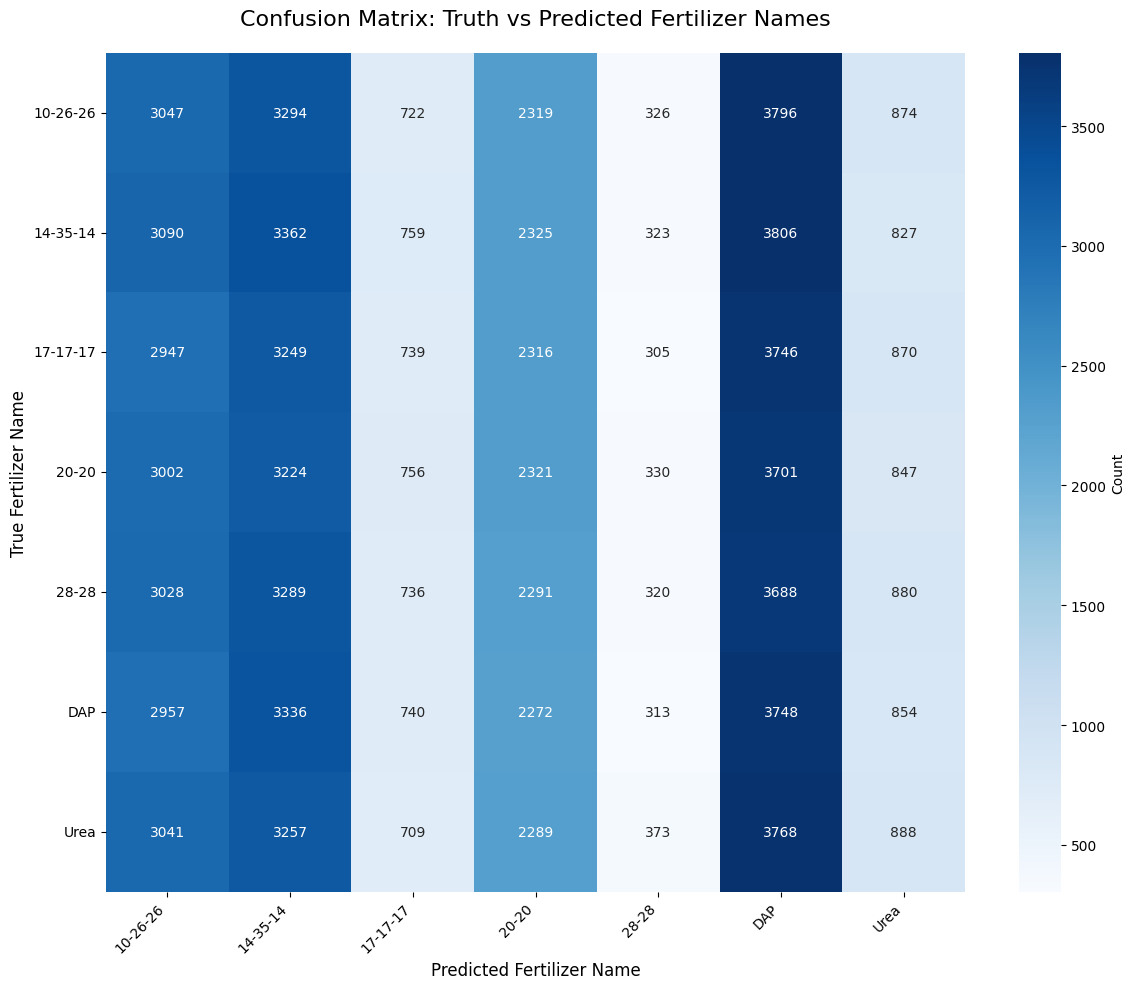

✓ Confusion matrix created with 7 classes


In [74]:
# Step 5: Create confusion matrix
print("\n5. Creating confusion matrix...")
try:
    # Get unique class names
    class_names = sorted(list(set(true_fertilizers) | set(predicted_fertilizers)))
    
    # Create confusion matrix
    cm = create_confusion_matrix(
        true_fertilizers, 
        predicted_fertilizers, 
        class_names,
        'custom_dataset_confusion_matrix.png'
    )
    
    print(f"✓ Confusion matrix created with {len(class_names)} classes")
    
except Exception as e:
    print(f"✗ Error creating confusion matrix: {e}")

In [75]:
# Step 6: Analyze and save detailed results
print("\n6. Analyzing and saving detailed results...")
try:
    analysis_df = analyze_predictions(evaluation_results, 'custom_dataset_analysis.csv')
    
    # Print some statistics
    print(f"\nPrediction Statistics:")
    print(f"  - Total samples: {len(analysis_df)}")
    print(f"  - Correct at 1st position: {analysis_df['is_correct_at_1'].sum()} ({analysis_df['is_correct_at_1'].mean():.3f})")
    print(f"  - Correct in top 3: {analysis_df['is_correct_in_top_3'].sum()} ({analysis_df['is_correct_in_top_3'].mean():.3f})")
    
    # Show distribution of true positions
    position_counts = analysis_df['true_position'].value_counts().sort_index()
    print(f"\nTrue Position Distribution:")
    for pos, count in position_counts.items():
        print(f"  - Position {pos}: {count} samples ({count/len(analysis_df):.3f})")
    
except Exception as e:
    print(f"✗ Error analyzing results: {e}")


6. Analyzing and saving detailed results...
✓ Detailed analysis saved to: custom_dataset_analysis.csv

Prediction Statistics:
  - Total samples: 100000
  - Correct at 1st position: 14425 (0.144)
  - Correct in top 3: 43157 (0.432)

True Position Distribution:
  - Position 1.0: 14425 samples (0.144)
  - Position 2.0: 14405 samples (0.144)
  - Position 3.0: 14327 samples (0.143)


In [76]:
# Step 7: Print sample predictions
print("\n7. Sample Predictions:")
print("-" * 80)

# Show first 10 predictions
for i in range(min(10, len(analysis_df))):
    row = analysis_df.iloc[i]
    print(f"Sample {i+1}:")
    print(f"  True: {row['true_fertilizer']}")
    print(f"  Predicted: {row['predicted_1st']} (prob: {row['probability_1st']:.3f})")
    print(f"  Correct: {row['is_correct_at_1']}")
    if row['true_position']:
        print(f"  True position: {row['true_position']}")
    print()



7. Sample Predictions:
--------------------------------------------------------------------------------
Sample 1:
  True: 14-35-14
  Predicted: DAP (prob: 0.179)
  Correct: False
  True position: 2.0

Sample 2:
  True: Urea
  Predicted: 20-20 (prob: 0.163)
  Correct: False
  True position: nan

Sample 3:
  True: 20-20
  Predicted: 10-26-26 (prob: 0.175)
  Correct: False
  True position: 3.0

Sample 4:
  True: 28-28
  Predicted: 14-35-14 (prob: 0.178)
  Correct: False
  True position: 3.0

Sample 5:
  True: 14-35-14
  Predicted: 10-26-26 (prob: 0.160)
  Correct: False
  True position: nan

Sample 6:
  True: Urea
  Predicted: DAP (prob: 0.228)
  Correct: False
  True position: nan

Sample 7:
  True: 10-26-26
  Predicted: DAP (prob: 0.197)
  Correct: False
  True position: 2.0

Sample 8:
  True: Urea
  Predicted: DAP (prob: 0.188)
  Correct: False
  True position: 2.0

Sample 9:
  True: 28-28
  Predicted: 14-35-14 (prob: 0.183)
  Correct: False
  True position: nan

Sample 10:
  True: 20

In [ ]:

# Step 8: Final summary
print("\n" + "="*60)
print("EVALUATION COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"✓ Dataset evaluated: {len(custom_df)} samples")
print(f"✓ Accuracy at 1st position: {evaluation_results['accuracy_at_1']:.5f}")
print(f"✓ MAP@3: {evaluation_results['map_at_k']:.5f}")
print(f"✓ Hit rate (top 3): {evaluation_results['hit_rate']:.5f}")
print(f"✓ Confusion matrix: custom_dataset_confusion_matrix.png")
print(f"✓ Detailed analysis: custom_dataset_analysis.csv")
print("="*60)